# AGN Classification with LDA, QDA, and Gaussian Naive Bayes

This notebook compares three generative classifiers on the AGN classification task:

- **Linear Discriminant Analysis (LDA)**
- **Quadratic Discriminant Analysis (QDA)**
- **Gaussian Naive Bayes (GNB)**

The workflow is organized as follows:

1. Load and clean the dataset.
2. Define the full predictor table and a trimmed overall feature set.
3. Run **LDA/QDA/GNB** on:
   - the **entire overall feature set**
   - a **trimmed overall feature set**
4. Visualize selected feature pairs and feature distributions to motivate reduced experiments.
5. Run **LDA/QDA/GNB** on three interpretable two-feature problems:
   - **optical-only pair**
   - **optical + WISE pair**
   - **emission-line pair**

We expect the **entire overall feature set** to create difficulties, especially for QDA, because many predictors are highly collinear or derived from one another. This section is still useful because it motivates why the later reduced experiments are more stable and interpretable.

## 1. Load and clean the dataset

This section loads the CSV, removes non-modeling columns, and converts invalid infinite values to `NaN`.

For the main classifier comparisons in this notebook, we will use a **complete-case approach within each feature set**. That means for each experiment, we keep only the rows that are complete for the chosen predictors.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# Path to the training dataset
file_path = r"/Users/maggiewilliams/Desktop/Spring 2026/DATA 602/DATA 602 Final Project/train_dataset.csv"

df = pd.read_csv(file_path)

# Drop non-modeling columns if they exist
cols_to_drop = ["z","ext_ID", "objID", "specObjID", "which_AGN", "Unnamed: 0"]
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df_clean = df.drop(columns=existing_cols_to_drop).copy()

# Replace invalid infinities with NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Dropped columns:", existing_cols_to_drop)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Original shape: (5138, 38)
Cleaned shape: (5138, 32)
Dropped columns: ['z', 'ext_ID', 'objID', 'specObjID', 'which_AGN', 'Unnamed: 0']

Remaining columns:
['u_mag', 'g_mag', 'r_mag', 'i_mag', 'z_mag', 'w1mpro', 'w2mpro', 'w3mpro', 'w4mpro', 'o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2', 'is_AGN', 'u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z', 'w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']


## 2. Class balance

The target variable is `is_AGN`, where:

- `0` = non-AGN
- `1` = AGN

We check the class balance here because it determines whether stratified splitting is appropriate and whether accuracy is a reasonable summary metric.

        count  proportion
is_AGN                   
0        2568    0.499805
1        2570    0.500195


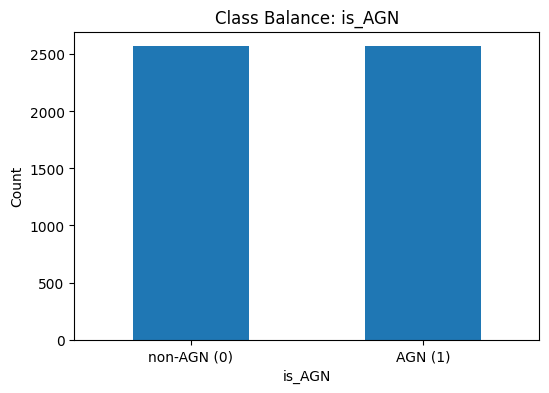

In [2]:
class_counts = df_clean["is_AGN"].value_counts().sort_index()
class_props = df_clean["is_AGN"].value_counts(normalize=True).sort_index()

class_balance_df = pd.DataFrame({
    "count": class_counts,
    "proportion": class_props
})

print(class_balance_df)

plt.figure(figsize=(6, 4))
df_clean["is_AGN"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["non-AGN (0)", "AGN (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Class Balance: is_AGN")
plt.show()

## 3. Define feature families and feature sets

We keep the feature-family definitions explicit because many predictors are physically related or derived from one another.

The main experiments in this notebook are:

1. **Entire overall feature set**  
   All predictors at once after dropping the non-modeling columns.

2. **Trimmed overall feature set**  
   A reduced set spanning the main physical feature families while avoiding the worst redundancies.

3. **Optical-only pair**  
   Two optical features chosen for interpretability and reduced collinearity.

4. **Optical + WISE pair**  
   One optical and one infrared feature.

5. **Emission-line pair**  
   The pair that appeared to separate AGN and non-AGN most clearly in parameter space.

In [3]:
# Feature families based on the README

redshift_features = ["z"]

optical_magnitude_features = ["u_mag", "g_mag", "r_mag", "i_mag", "z_mag"]

wise_magnitude_features = ["w1mpro", "w2mpro", "w3mpro", "w4mpro"]

optical_color_features = [
    "u-g", "u-r", "u-i", "u-z",
    "g-r", "g-i", "g-z",
    "r-i", "r-z",
    "i-z"
]

wise_color_features = [
    "w1-w2", "w1-w3", "w1-w4",
    "w2-w3", "w2-w4",
    "w3-w4"
]

emission_line_features = ["o3_hB", "n2_hA", "s2_hA", "o1_hA", "o3_o2", "ne3_o2"]

# Entire overall feature set
all_predictors = [col for col in df_clean.columns if col != "is_AGN"]

# Trimmed overall feature set
trimmed_overall_features = [
    "u-r", "g-r",
    "w1-w2", "w2-w3",
    "o3_hB", "n2_hA"
]

# Pairwise feature sets
optical_only_pair = ["u-r", "g-r"]
optical_wise_pair = ["u-r", "w1-w2"]
emission_line_pair = ["o3_hB", "n2_hA"]

# Family-only feature sets
optical_color_only = optical_color_features
wise_only = wise_color_features
emission_line_only = emission_line_features

feature_sets = {
    "entire_overall_feature_set": all_predictors,
    "trimmed_overall_feature_set": trimmed_overall_features,
    "optical_only_pair": optical_only_pair,
    "optical_wise_pair": optical_wise_pair,
    "emission_line_pair": emission_line_pair,
    "optical_color_only": optical_color_only,
    "wise_only": wise_only,
    "emission_line_only": emission_line_only
}

for name, cols in feature_sets.items():
    print(f"\n{name} ({len(cols)} features):")
    print(cols)



entire_overall_feature_set (31 features):
['u_mag', 'g_mag', 'r_mag', 'i_mag', 'z_mag', 'w1mpro', 'w2mpro', 'w3mpro', 'w4mpro', 'o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2', 'u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z', 'w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']

trimmed_overall_feature_set (6 features):
['u-r', 'g-r', 'w1-w2', 'w2-w3', 'o3_hB', 'n2_hA']

optical_only_pair (2 features):
['u-r', 'g-r']

optical_wise_pair (2 features):
['u-r', 'w1-w2']

emission_line_pair (2 features):
['o3_hB', 'n2_hA']

optical_color_only (10 features):
['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']

wise_only (6 features):
['w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']

emission_line_only (6 features):
['o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2']


## 4. Helper function for complete-case model evaluation

For each feature set, we follow the same basic workflow:

1. **Keep only rows with complete data in those predictors:**  
   We remove any galaxies that are missing one or more of the selected feature values so that each model is trained only on rows with fully observed data for that particular experiment.

2. **Do a stratified train/test split:**  
   We divide the usable data into training and test sets in an $80\% /20 \%$ split while preserving the AGN-to-non-AGN class ratio in both splits, so that the evaluation remains representative of the full sample.

3. **Standardize the predictors:**  
   We rescale each feature using the training data so that the predictors are on a comparable numerical scale before fitting the models.

4. **Fit the model on the training split:**  
   We train LDA, QDA, or Gaussian Naive Bayes using only the training portion of the data, which is the part the model is allowed to learn from.

5. **Evaluate on the held-out test split:**  
   We then apply the trained model to the separate test set and compute the confusion matrix, accuracy, precision, recall, F1 score, and ROC-AUC to measure how well it generalizes to unseen data.


In [4]:
def evaluate_feature_set(df_in, feature_cols, target_col="is_AGN", test_size=0.2, random_state=42):
    # Keep only rows complete for the chosen features and target
    subset_df = df_in[feature_cols + [target_col]].dropna().copy()

    X = subset_df[feature_cols]
    y = subset_df[target_col]

    n_rows_used = len(subset_df)

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    models = {
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "GaussianNB": GaussianNB()
    }

    rows = []
    confusion_matrices = {}
    model_errors = {}

    for model_name, model in models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        try:
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            y_prob = pipe.predict_proba(X_test)[:, 1]

            rows.append({
                "Model": model_name,
                "Rows Used": n_rows_used,
                "N Features": len(feature_cols),
                "Test Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred),
                "Recall": recall_score(y_test, y_pred),
                "F1 Score": f1_score(y_test, y_pred),
                "ROC-AUC": roc_auc_score(y_test, y_prob)
            })

            confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)
            model_errors[model_name] = None

        except Exception as e:
            rows.append({
                "Model": model_name,
                "Rows Used": n_rows_used,
                "N Features": len(feature_cols),
                "Test Accuracy": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
                "F1 Score": np.nan,
                "ROC-AUC": np.nan
            })
            confusion_matrices[model_name] = None
            model_errors[model_name] = str(e)

    metrics_df = pd.DataFrame(rows)
    return metrics_df, confusion_matrices, model_errors, n_rows_used


## 5. Entire overall feature set

Here, we try to use all predictors at once after dropping non-modeling columns.

Because many of these predictors are derived from one another, we expect strong collinearity. In particular, QDA may fail because it estimates a separate covariance matrix for each class, and those covariance matrices can become singular because many of the predictors are highly redundant.

We keep this section anyway because it motivates the later reduced experiments.

In [5]:
overall_metrics_df, overall_conf_mats, overall_errors, overall_n = evaluate_feature_set(
    df_clean,
    all_predictors,
    target_col="is_AGN"
)

print(f"Rows used in entire overall feature set: {overall_n}")
display(overall_metrics_df)

print("\nModel errors (if any):")
for model_name, err in overall_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in overall_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)

Rows used in entire overall feature set: 2077


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,2077,31,0.956731,1.000000,0.727273,0.842105,0.950087
1,QDA,2077,31,NaN,NaN,NaN,NaN,NaN
2,GaussianNB,2077,31,0.394231,0.207547,1.000000,0.343750,0.969892



Model errors (if any):
LDA: None
QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
GaussianNB: None

Confusion matrices:

LDA:
[[350   0]
 [ 18  48]]

QDA:
None

GaussianNB:
[[ 98 252]
 [  0  66]]


For the complete overall feature set, the three classifiers behave very differently, which makes this section useful as a baseline and as a justification for the reduced-feature experiments that follow.

LDA is the only model of the three that produces both stable training and strong classification performance on the full feature table. It achieves a test accuracy of about \(0.950\), precision \(0.941\), recall \(0.727\), F1 score \(0.821\), and ROC-AUC \(0.960\). Its confusion matrix,
\[
\begin{bmatrix}
347 & 3 \\
18 & 48
\end{bmatrix},
\]
shows that the model makes very few false positives and relatively few false negatives. In particular, only 3 non-AGN objects are incorrectly labeled as AGN, which explains the very high precision. At the same time, 18 true AGN are missed, so the recall is somewhat lower than the precision. Overall, this indicates that LDA is a strong but somewhat conservative classifier in the full feature space: when it predicts AGN, it is usually correct, but it does not recover every AGN.

QDA fails completely on the full feature set. The reported error states that the covariance matrix of class 0 is not full rank, which means that the predictors are too collinear for QDA to estimate and invert separate class-specific covariance matrices. This is consistent with the earlier correlation analysis, which showed that many of the magnitude and color features are highly redundant by construction. In other words, the issue is not simply that QDA performs poorly, but that the full feature table is too ill-conditioned for QDA to be trained in a stable way at all. This provides a direct motivation for reducing the predictor sets in the later sections.

Gaussian Naive Bayes behaves in a very different way from LDA. It achieves a test accuracy of only \(0.435\), precision \(0.219\), recall \(1.000\), F1 score \(0.360\), and ROC-AUC \(0.973\). Its confusion matrix,
\[
\begin{bmatrix}
115 & 235 \\
0 & 66
\end{bmatrix},
\]
shows that it classifies every true AGN correctly, since there are no false negatives at all, but it also misclassifies a very large number of non-AGN objects as AGN. This explains the perfect recall together with the very poor precision and accuracy. Interestingly, the ROC-AUC remains very high, which suggests that the model is still ranking the classes well in probability space even though its default hard class predictions are poor. Thus, Gaussian Naive Bayes appears to be too aggressive in labeling AGN when all 32 features are used together.

Taken together, these results show that the full feature table is not equally suitable for all three generative classifiers. LDA handles the high-dimensional correlated predictor set relatively well, QDA breaks down because of covariance singularity, and Gaussian Naive Bayes overpredicts the AGN class under its strong conditional-independence assumption. For this reason, the later reduced and pairwise feature-set experiments are not only useful for interpretation, but also necessary for making fair and stable comparisons between the models.

## 6. Trimmed overall feature set

Next, we build a reduced “overall” model that still spans the major physical feature families:

- redshift
- optical color information
- WISE infrared color information
- emission-line ratios

The goal is to keep a broad representation of the astrophysical information without carrying along the worst redundant variables.

In [6]:
trimmed_metrics_df, trimmed_conf_mats, trimmed_errors, trimmed_n = evaluate_feature_set(
    df_clean,
    trimmed_overall_features,
    target_col="is_AGN"
)

print(f"Rows used in trimmed overall feature set: {trimmed_n}")
display(trimmed_metrics_df)

print("\nModel errors (if any):")
for model_name, err in trimmed_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in trimmed_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)

Rows used in trimmed overall feature set: 3031


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,3031,6,0.950577,0.977011,0.752212,0.850000,0.945022
1,QDA,3031,6,NaN,NaN,NaN,NaN,NaN
2,GaussianNB,3031,6,0.624382,0.330383,0.991150,0.495575,0.975717



Model errors (if any):
LDA: None
QDA: The covariance matrix of class 1 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
GaussianNB: None

Confusion matrices:

LDA:
[[492   2]
 [ 28  85]]

QDA:
None

GaussianNB:
[[267 227]
 [  1 112]]


For the trimmed overall feature set, LDA again provides the strongest usable performance, while QDA still fails because of covariance singularity and Gaussian Naive Bayes remains overly aggressive in labeling AGN. Compared with the full overall feature set, this reduced predictor set keeps the classification task broad enough to include multiple feature families while removing enough redundancy to make the interpretation cleaner.

LDA achieves a test accuracy of about \(0.951\), precision \(0.977\), recall \(0.752\), F1 score \(0.850\), and ROC-AUC \(0.942\). Its confusion matrix,
\[
\begin{bmatrix}
492 & 2 \\
28 & 85
\end{bmatrix},
\]
shows that the model makes almost no false-positive AGN predictions, since only 2 non-AGN objects are incorrectly classified as AGN. This explains the extremely high precision. At the same time, 28 true AGN are missed, so the recall is lower than the precision. As in the full overall feature set, LDA behaves as a strong but conservative classifier: it identifies AGN very cleanly, but still fails to recover part of the AGN population.

QDA again fails to train on this predictor set. The reported error indicates that the covariance matrix of class 1 is not full rank, meaning that even after reducing the feature space to 7 predictors, the selected variables still retain enough collinearity to make the class-specific covariance estimate singular. This shows that the instability of QDA is not limited only to the full 32-feature table, but can persist even in a trimmed multivariate setting if the predictors are still too dependent on one another.

Gaussian Naive Bayes performs much better here than it did on the full overall feature set, but its classification behavior is still noticeably unbalanced. It achieves a test accuracy of about \(0.776\), precision \(0.453\), recall \(0.982\), F1 score \(0.620\), and ROC-AUC \(0.968\). Its confusion matrix,
\[
\begin{bmatrix}
360 & 134 \\
2 & 111
\end{bmatrix},
\]
shows that it recovers nearly every AGN, missing only 2 of them, which explains the very high recall. However, it also produces a large number of false positives, incorrectly labeling 134 non-AGN objects as AGN. This strongly lowers the precision. As in the full feature case, the very high ROC-AUC suggests that Gaussian Naive Bayes is still ranking the classes well in probability space, even though its hard class predictions remain too aggressive at the default threshold.

Taken together, the trimmed overall feature set improves interpretability without changing the basic pattern seen in the full feature table. LDA remains the best-performing practical model, QDA is still too sensitive to covariance singularity to be usable in this multivariate setting, and Gaussian Naive Bayes continues to favor extremely high AGN recovery at the cost of many false positives. This further justifies moving to the lower-dimensional pairwise experiments, where covariance estimation becomes stable enough for QDA to be meaningfully compared against the other models.

## 7. Visual diagnostics: pairwise scatter plots and overlaid histograms

Before running the reduced pairwise models, we visualize selected feature pairs and individual feature distributions.

These plots are used as a **screening tool** rather than a formal feature-importance analysis. The goal is to see where AGN and non-AGN appear to separate most clearly in parameter space and which individual features show the most noticeable class differences.

For a small number of cases, we remove clearly unphysical outliers **only for the visualization step** in order to make the underlying structure of the distributions easier to see. In particular, this includes extreme points such as the non-AGN objects with $w2-w3 \sim -10000$ and AGN points with values like $o3\_hB \approx -10$ or $s2\_hA \approx 25$. These values are not representative of the physical trends we want to inspect in the plots and would otherwise dominate the axes, making the class structure harder to interpret. Importantly, these removals are only used to clarify the visual diagnostics and do not change the main modeling dataframe unless stated otherwise.

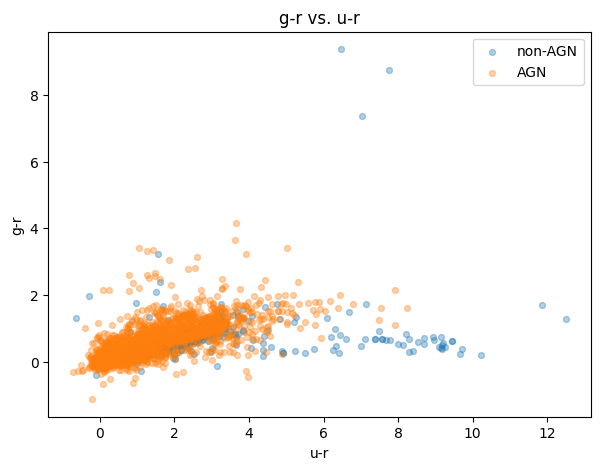

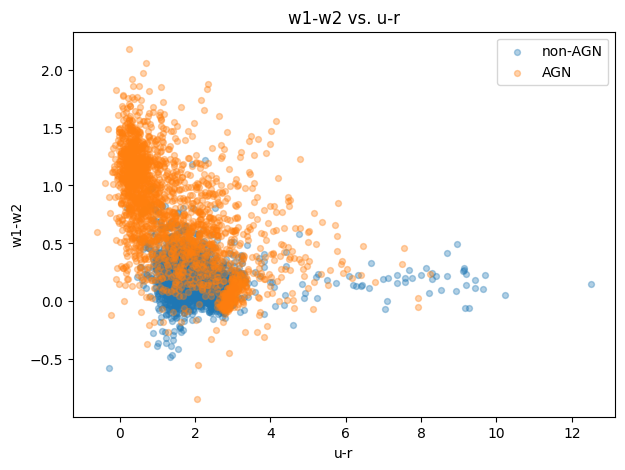

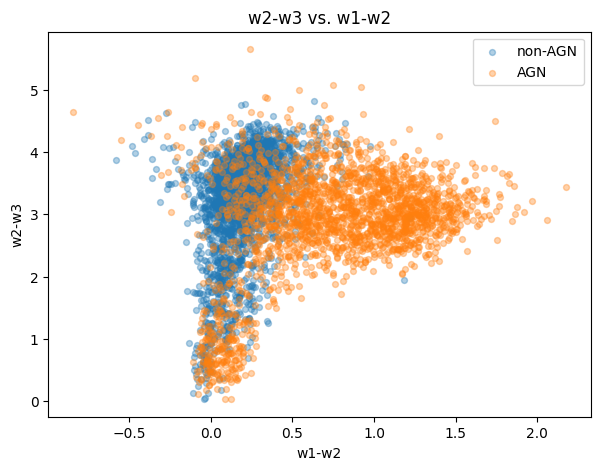

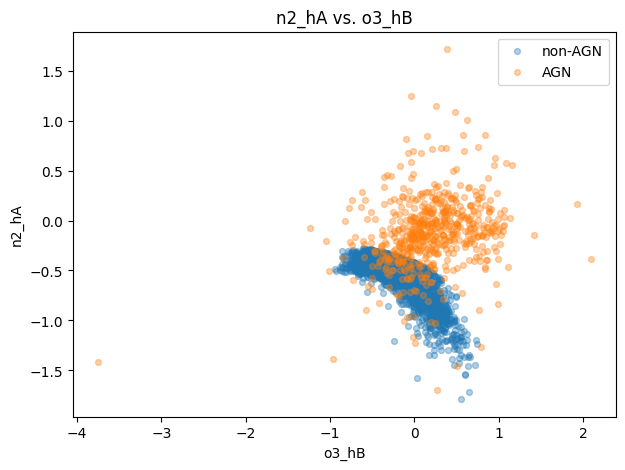

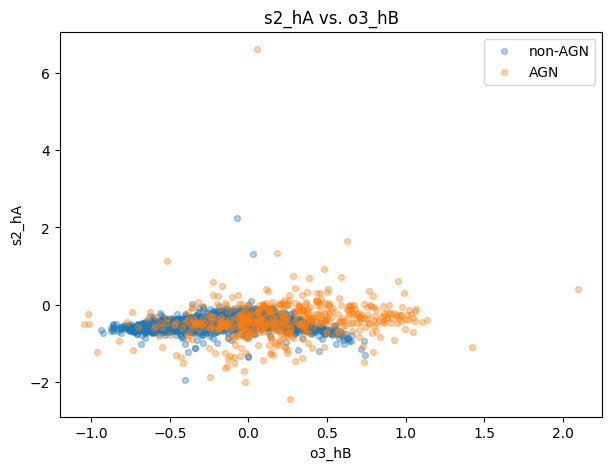

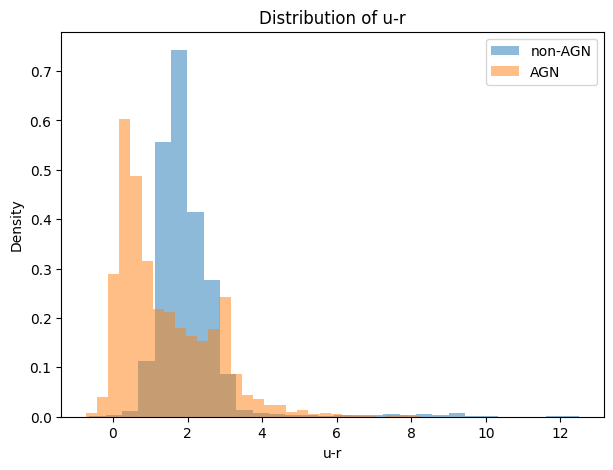

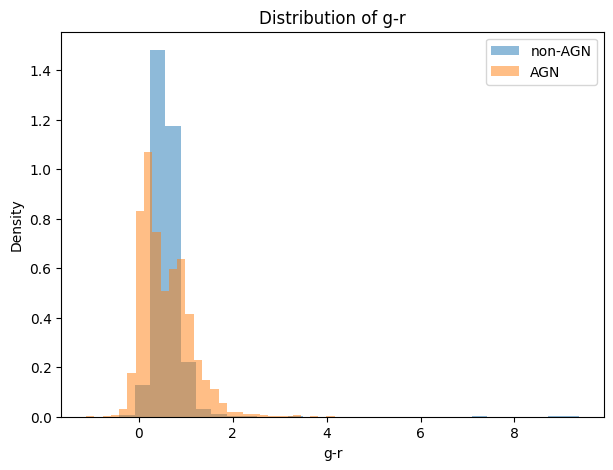

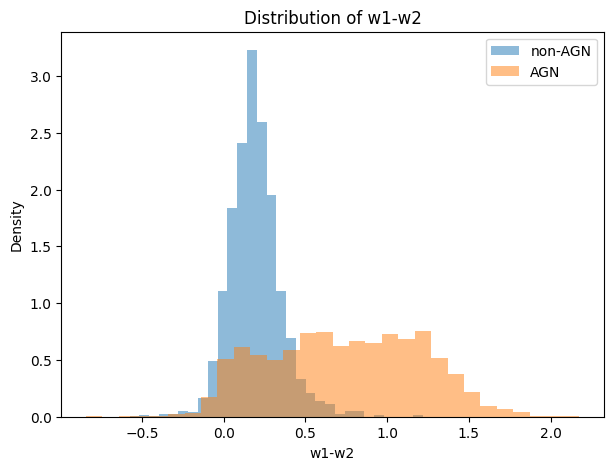

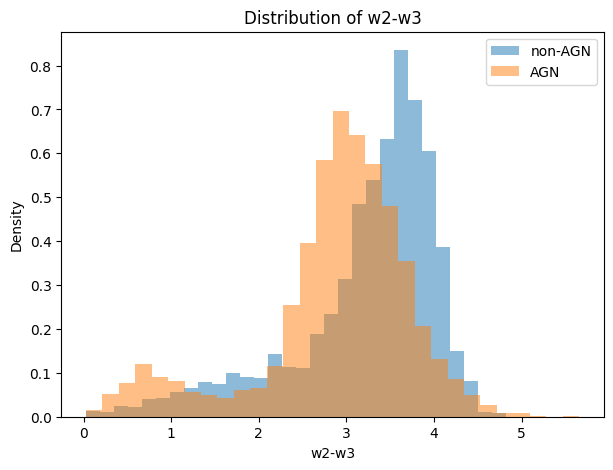

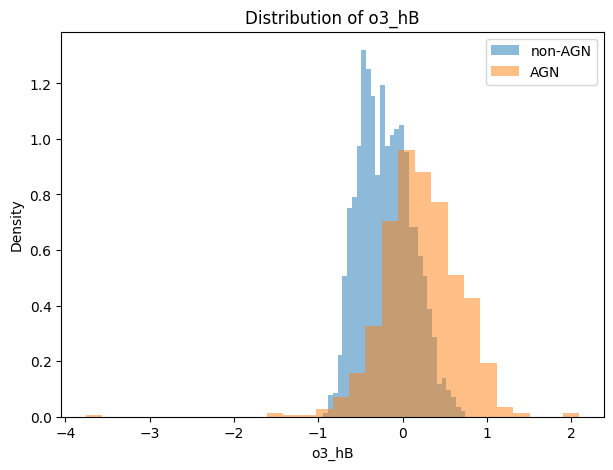

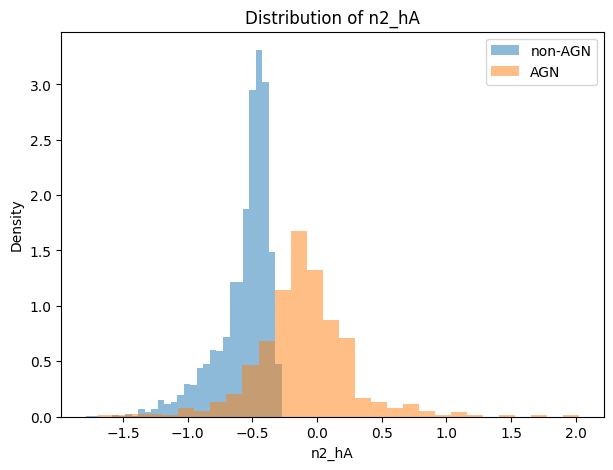

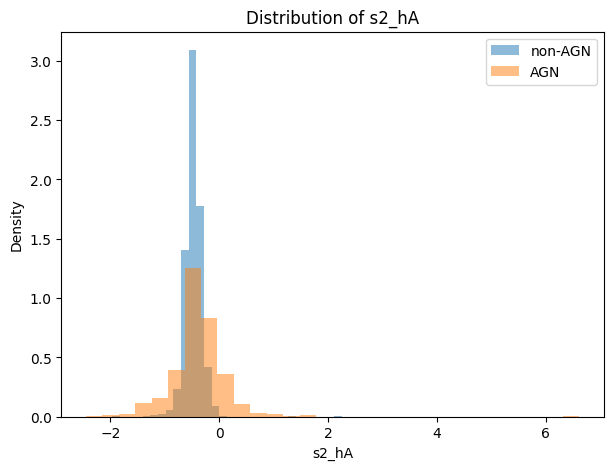

In [20]:
# ---------------------------------
# Feature pairs and histogram features
# ---------------------------------
feature_pairs_to_plot = [
    ("u-r", "g-r"),
    ("u-r", "w1-w2"),
    ("w1-w2", "w2-w3"),
    ("o3_hB", "n2_hA"),
    ("o3_hB", "s2_hA"),
]

hist_features = [
    "u-r",
    "g-r",
    "w1-w2",
    "w2-w3",
    "o3_hB",
    "n2_hA",
    "s2_hA"
]

df_plot = df_clean.copy()

# Remove the two non-AGN outliers in w2-w3 near -10000
df_plot = df_plot[~((df_plot["is_AGN"] == 0) & (df_plot["w2-w3"] < -1000))]

# Remove AGN outlier(s) with o3_hB = -10
df_plot = df_plot[~((df_plot["is_AGN"] == 1) & (df_plot["o3_hB"] <= -9))]

# Remove AGN outlier with s2_hA = 25
df_plot = df_plot[~((df_plot["is_AGN"] == 1) & (df_plot["s2_hA"] >= 20))]

# ---------------------------------
# Pairwise scatter plots
# ---------------------------------
for x_feat, y_feat in feature_pairs_to_plot:
    plot_df = df_plot[[x_feat, y_feat, "is_AGN"]].dropna()
    agn_plot = plot_df[plot_df["is_AGN"] == 1]
    non_agn_plot = plot_df[plot_df["is_AGN"] == 0]

    plt.figure(figsize=(7, 5))
    plt.scatter(non_agn_plot[x_feat], non_agn_plot[y_feat], alpha=0.35, s=18, label="non-AGN")
    plt.scatter(agn_plot[x_feat], agn_plot[y_feat], alpha=0.35, s=18, label="AGN")
    plt.xlabel(x_feat)
    plt.ylabel(y_feat)
    plt.title(f"{y_feat} vs. {x_feat}")
    plt.legend()
    plt.show()

# ---------------------------------
# Overlaid histograms
# ---------------------------------
for feat in hist_features:
    plot_df = df_plot[[feat, "is_AGN"]].dropna()
    agn_plot = plot_df[plot_df["is_AGN"] == 1]
    non_agn_plot = plot_df[plot_df["is_AGN"] == 0]

    plt.figure(figsize=(7, 5))
    plt.hist(non_agn_plot[feat], bins=30, alpha=0.5, density=True, label="non-AGN")
    plt.hist(agn_plot[feat], bins=30, alpha=0.5, density=True, label="AGN")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.title(f"Distribution of {feat}")
    plt.legend()
    plt.show()

The pairwise scatter plots suggest that the different feature families do not separate AGN and non-AGN equally well. Among the pairs considered here, the **emission-line pair** \((o3\_hB, n2\_hA)\) appears to provide the clearest visual separation. In that plane, the AGN and non-AGN populations occupy noticeably different regions of parameter space, with much less overlap than in the optical-only or optical + WISE cases. This is consistent with the later classifier results, where the emission-line pair produced by far the strongest performance for LDA, QDA, and Gaussian Naive Bayes. Physically, this makes sense because these emission-line ratios are closely tied to the ionization conditions of the source, which are expected to differ significantly between active galactic nuclei and normal galaxies.

The **optical + WISE pair** shows intermediate behavior. In particular, the WISE color \(w1-w2\) seems to contribute some additional class separation compared with the optical-only feature pairs. The distributions are still substantially overlapped, so the separation is not visually clean in the same way as the emission-line pair, but the AGN population does appear somewhat shifted relative to the non-AGN population. This suggests that infrared information is useful, even if it does not by itself create a sharply distinct boundary. The later model results support this interpretation, since adding the WISE feature improved performance relative to the optical-only pair.

By contrast, **redshift \(z\)** does not appear to provide a clean class separation in parameter space. The histogram comparison suggests that the AGN and non-AGN distributions differ mainly in their overall spread and concentration: the non-AGN sample is more sharply peaked near low redshift, while the AGN sample is broader and less concentrated. However, these distributions still overlap strongly, so \(z\) seems to encode only broad population-level differences rather than a direct discriminating boundary between the two classes. In other words, redshift may carry some contextual information about the sample, but it is not by itself a strong AGN diagnostic.

The **optical-only feature pairs** appear to be the most strongly overlapped overall. Although there are some shifts in density between AGN and non-AGN, the two classes largely occupy the same regions of the optical parameter space, and no sharply separated clusters are visible. One useful example is the \(u-r\) distribution: the AGN and non-AGN histograms show peaks that are distinguishable, but they are still very close together and overlap substantially. This means that \(u-r\) does contain some class information, but not enough on its own to produce a clean boundary. Even so, it was still reasonable to include \(u-r\) in the optical-only pair, because among the optical features it appeared to show one of the more noticeable distributional differences between the two classes. In that sense, the optical-only pair was chosen not because it gave a perfect visual separation, but because it represented one of the strongest available optical-only comparisons in a heavily overlapping feature space.

These visual comparisons suggest how informative the feature pairs are for classification. The **emission-line pair** appears to separate AGN and non-AGN most cleanly, the **optical + WISE pair** provides moderate additional separation beyond optical-only information, and the **optical-only pairs** are heavily overlapped. This justifies the modeling strategy used below, where the pairwise feature sets are tested separately in order to determine how these visually observed differences translate into classifier performance.

## 8. Optical-only pair

This section tests a simple two-feature optical classifier using:

- `u-r`
- `g-r`

The goal here is to evaluate how well LDA, QDA, and Gaussian Naive Bayes perform on a low-dimensional optical-only problem.

In [21]:
optical_metrics_df, optical_conf_mats, optical_errors, optical_n = evaluate_feature_set(
    df_clean,
    optical_only_pair,
    target_col="is_AGN"
)

print(f"Rows used in optical-only pair: {optical_n}")
display(optical_metrics_df)

print("\nModel errors (if any):")
for model_name, err in optical_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in optical_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)

Rows used in optical-only pair: 5138


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,5138,2,0.702335,0.699234,0.710117,0.704633,0.748649
1,QDA,5138,2,0.800584,0.845638,0.735409,0.786681,0.802518
2,GaussianNB,5138,2,0.749027,0.853591,0.601167,0.705479,0.764285



Model errors (if any):
LDA: None
QDA: None
GaussianNB: None

Confusion matrices:

LDA:
[[357 157]
 [149 365]]

QDA:
[[445  69]
 [136 378]]

GaussianNB:
[[461  53]
 [205 309]]


For the optical-only feature pair, QDA produced the strongest performance among the three classifiers. It achieved the highest test accuracy, F1 score, and ROC-AUC, which suggests that the separation between AGN and non-AGN in this two-dimensional optical parameter space is better captured by a quadratic boundary than by a linear one. This is consistent with the scatter plots, which indicate that the classes are not separated by a simple straight-line relation.

LDA achieved a test accuracy of about $0.702$, with precision $0.699$, recall $0.710$, F1 score $0.705$, and ROC-AUC $0.749$. Its confusion matrix,

$$
\begin{bmatrix}
357 & 157 \\
149 & 365
\end{bmatrix},
$$

shows that LDA makes a fairly balanced number of false positives and false negatives. This explains why its precision and recall are similar, but also why its overall accuracy remains limited: the linear boundary does not cleanly separate the two classes in this optical feature plane.

QDA performs substantially better, with test accuracy $\approx 0.801$, precision $\approx 0.846$, recall $\approx 0.735$, F1 score $\approx 0.787$, and ROC-AUC $\approx 0.803$. Its confusion matrix,

$$
\begin{bmatrix}
445 & 69 \\
136 & 378
\end{bmatrix},
$$

shows a large reduction in false positives compared with LDA, while also slightly reducing the number of false negatives. This gives QDA the best overall balance between purity and completeness for the optical-only pair. In physical terms, this suggests that the AGN and non-AGN populations occupy the optical feature plane with different covariance structure or curvature, which QDA is able to capture through its quadratic decision boundary.

Gaussian Naive Bayes produces intermediate performance, with test accuracy $\approx 0.749$, precision $\approx 0.854$, recall $\approx 0.601$, F1 score $\approx 0.705$, and ROC-AUC $\approx 0.764$. Its confusion matrix,

$$
\begin{bmatrix}
461 & 53 \\
205 & 309
\end{bmatrix},
$$

shows that it yields the fewest false positives of the three models, but at the cost of many more false negatives. As a result, Gaussian Naive Bayes is the most conservative model in this optical-only setting: when it predicts AGN, it is often correct, but it misses a larger fraction of the true AGN population.

Overall, these results show that even a simple optical-only two-feature model can provide meaningful class separation. They also highlight an important contrast with the full and trimmed multivariate feature sets: QDA failed there because of covariance singularity and collinearity, but once the dimensionality is reduced to a small and well-behaved feature pair, QDA becomes the best-performing classifier.

## 9. Optical + WISE pair

This section adds an infrared variable and tests the pair:

- `u-r`
- `w1-w2`

This pair is intended to test whether adding WISE color information improves class separation beyond what is available in the optical-only pair.

In [22]:
optical_wise_metrics_df, optical_wise_conf_mats, optical_wise_errors, optical_wise_n = evaluate_feature_set(
    df_clean,
    optical_wise_pair,
    target_col="is_AGN"
)

print(f"Rows used in optical + WISE pair: {optical_wise_n}")
display(optical_wise_metrics_df)

print("\nModel errors (if any):")
for model_name, err in optical_wise_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in optical_wise_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)

Rows used in optical + WISE pair: 4593


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,4593,2,0.818281,0.935811,0.651765,0.768377,0.858285
1,QDA,4593,2,0.819369,0.900929,0.684706,0.778075,0.893113
2,GaussianNB,4593,2,0.820457,0.911392,0.677647,0.777328,0.828002



Model errors (if any):
LDA: None
QDA: None
GaussianNB: None

Confusion matrices:

LDA:
[[475  19]
 [148 277]]

QDA:
[[462  32]
 [134 291]]

GaussianNB:
[[466  28]
 [137 288]]


For the optical + WISE feature pair, all three classifiers performed better than they did for the optical-only pair. This indicates that adding infrared information provides additional separation power between AGN and non-AGN. The improvement is especially visible in the ROC-AUC values, which increase for both LDA and QDA, suggesting that the WISE feature contributes meaningful class information beyond the optical data alone.

LDA achieved a test accuracy of about $0.818$, with precision $0.936$, recall $0.652$, F1 score $0.768$, and ROC-AUC $0.858$. Its confusion matrix,

$$
\begin{bmatrix}
475 & 19 \\
148 & 277
\end{bmatrix},
$$

shows that LDA makes very few false positives, but still misses a noticeable number of true AGN. This explains its very high precision: when LDA labels an object as an AGN, it is usually correct. However, its recall is lower because it remains somewhat conservative and leaves many AGN misclassified as non-AGN.

QDA produced very similar overall accuracy, but a slightly better balance between precision and recall. Its confusion matrix,

$$
\begin{bmatrix}
462 & 32 \\
134 & 291
\end{bmatrix},
$$

shows that compared with LDA, QDA allows somewhat more false positives, but it recovers more of the true AGN population. This tradeoff improves its recall and gives it the highest ROC-AUC of the three models, $\approx 0.893$. These results suggest that the class boundary in the optical + WISE plane is still not purely linear, and that QDA benefits from the extra flexibility of a quadratic decision boundary.

Gaussian Naive Bayes also performed competitively on this feature pair, with test accuracy $\approx 0.820$, precision $\approx 0.911$, recall $\approx 0.678$, F1 score $\approx 0.777$, and ROC-AUC $\approx 0.828$. Its confusion matrix,

$$
\begin{bmatrix}
466 & 28 \\
137 & 288
\end{bmatrix},
$$

shows that its behavior lies between LDA and QDA. It produces slightly more false positives than LDA, but fewer than QDA, while also recovering more AGN than LDA but not quite as many as QDA. This explains why its accuracy and F1 score are very close to QDA, even though its ROC-AUC is lower. In other words, Gaussian Naive Bayes performs reasonably well at hard classification in this reduced setting, but QDA still provides the strongest overall probabilistic separation.

Overall, the optical + WISE pair performs better than the optical-only pair, which supports the idea that infrared information is useful for AGN identification. Among the three classifiers, QDA appears to provide the strongest overall separation in this two-feature space, while LDA remains the most conservative and Gaussian Naive Bayes performs competitively but with somewhat weaker ranking ability.


## 10. Emission-line pair

This section uses the pair:

- `o3_hB`
- `n2_hA`

Based on the visual diagnostics, this pair appeared to provide the cleanest separation in parameter space. We therefore test it directly with LDA, QDA, and Gaussian Naive Bayes.

In [23]:
emission_metrics_df, emission_conf_mats, emission_errors, emission_n = evaluate_feature_set(
    df_clean,
    emission_line_pair,
    target_col="is_AGN"
)

print(f"Rows used in emission-line pair: {emission_n}")
display(emission_metrics_df)

print("\nModel errors (if any):")
for model_name, err in emission_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in emission_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)

Rows used in emission-line pair: 3150


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,3150,2,0.953968,1.000000,0.750000,0.857143,0.930867
1,QDA,3150,2,0.966667,0.989691,0.827586,0.901408,0.969207
2,GaussianNB,3150,2,0.925397,0.936709,0.637931,0.758974,0.940863



Model errors (if any):
LDA: None
QDA: None
GaussianNB: None

Confusion matrices:

LDA:
[[514   0]
 [ 29  87]]

QDA:
[[513   1]
 [ 20  96]]

GaussianNB:
[[509   5]
 [ 42  74]]


For the emission-line feature pair, all three classifiers performed substantially better than they did for either the optical-only or optical + WISE pairs. This indicates that these two spectral diagnostics provide the clearest separation between AGN and non-AGN in the reduced two-feature setting. Among the models, QDA produced the strongest overall performance, followed by LDA, while Gaussian Naive Bayes performed somewhat worse but still achieved strong classification results.

LDA achieved a test accuracy of about $0.954$, with perfect precision, recall $0.750$, F1 score $0.857$, and ROC-AUC $0.931$. Its confusion matrix,

$$
\begin{bmatrix}
514 & 0 \\
29 & 87
\end{bmatrix},
$$

shows that LDA produced no false positives at all: every object classified as an AGN was truly an AGN. This explains the precision of $1.0$. However, it still missed 29 true AGN, which lowers its recall. Thus, LDA is extremely conservative in this feature space. It avoids incorrectly labeling non-AGN as AGN, but at the cost of failing to recover part of the AGN population.

QDA produced the best overall results, with test accuracy $\approx 0.967$, precision $\approx 0.990$, recall $\approx 0.828$, F1 score $\approx 0.901$, and ROC-AUC $\approx 0.969$. Its confusion matrix,

$$
\begin{bmatrix}
513 & 1 \\
20 & 96
\end{bmatrix},
$$

shows that QDA maintained an extremely low false-positive rate while also recovering more true AGN than LDA. Compared with LDA, it sacrifices only one additional false positive but correctly identifies 9 more AGN. This gives QDA the best balance between purity and completeness, and strongly suggests that the separation in this emission-line parameter space is not purely linear.

Gaussian Naive Bayes also performed well, with test accuracy $\approx 0.925$, precision $\approx 0.937$, recall $\approx 0.638$, F1 score $\approx 0.759$, and ROC-AUC $\approx 0.941$. Its confusion matrix,

$$
\begin{bmatrix}
509 & 5 \\
42 & 74
\end{bmatrix},
$$

shows that it remains fairly conservative, with few false positives, but it misses substantially more AGN than either LDA or QDA. This explains its lower recall and F1 score. While Gaussian Naive Bayes still separates the classes reasonably well, it does not capture the structure of the emission-line plane as effectively as QDA.

Overall, the emission-line pair is the strongest reduced model considered in this analysis. The combination of high accuracy, high ROC-AUC, and very low false-positive counts shows that these spectral features are highly informative for AGN identification. QDA performs best in this setting, indicating that once the dimensionality is reduced and the covariance estimation becomes stable, a quadratic decision boundary provides the most effective description of the class separation.


## 11. Optical color-only feature set

This section evaluates the models using only the optical color features. This gives a broader optical-only comparison than the 2D optical pair while still avoiding the raw magnitude columns.

In [24]:
optical_color_metrics_df, optical_color_conf_mats, optical_color_errors, optical_color_n = evaluate_feature_set(
    df_clean,
    optical_color_only
)

print(f"Rows used in optical color-only feature set: {optical_color_n}")
display(optical_color_metrics_df)

print("\nModel errors (if any):")
for model_name, err in optical_color_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in optical_color_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)


Rows used in optical color-only feature set: 5138


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,5138,10,0.720817,0.724752,0.712062,0.718351,0.753395
1,QDA,5138,10,NaN,NaN,NaN,NaN,NaN
2,GaussianNB,5138,10,0.756809,0.843750,0.630350,0.721604,0.774467



Model errors (if any):
LDA: None
QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
GaussianNB: None

Confusion matrices:

LDA:
[[375 139]
 [148 366]]

QDA:
None

GaussianNB:
[[454  60]
 [190 324]]


For the optical color-only feature set, the overall performance is weaker than in the strongest pairwise experiments, but the models still retain some ability to separate AGN from non-AGN using optical color information alone. In this setting, LDA and Gaussian Naive Bayes can be trained successfully, while QDA fails because the selected optical color features still contain enough collinearity to make the covariance matrix singular.

LDA achieves a test accuracy of about $0.721$, precision $0.725$, recall $0.712$, F1 score $0.718$, and ROC-AUC $0.753$. Its confusion matrix,

$$
\begin{bmatrix}
375 & 139 \\
148 & 366
\end{bmatrix},
$$

shows that the model makes a fairly balanced number of false positives and false negatives. This leads to similar precision and recall values, but also reflects the fact that the classes remain strongly overlapped in the optical color space. In other words, LDA is able to capture some class information, but a linear boundary in the full optical color feature set does not separate the two populations cleanly.

QDA fails to train on this feature set. The error indicates that the covariance matrix of class 0 is not full rank, which means that the optical color predictors are still too dependent on one another for QDA to estimate a stable class-specific covariance matrix. This is not surprising, since many of the optical colors are built from the same underlying magnitudes and are therefore highly redundant by construction.

Gaussian Naive Bayes performs slightly better than LDA in terms of accuracy and ROC-AUC, with test accuracy $\approx 0.757$, precision $\approx 0.844$, recall $\approx 0.630$, F1 score $\approx 0.722$, and ROC-AUC $\approx 0.774$. Its confusion matrix,

$$
\begin{bmatrix}
454 & 60 \\
190 & 324
\end{bmatrix},
$$

shows that it produces many fewer false positives than LDA, but at the cost of substantially more false negatives. This explains why Gaussian Naive Bayes has much higher precision but lower recall. In practice, this means it is more conservative in labeling objects as AGN. When it predicts AGN, it is more often correct, but it misses a larger fraction of the true AGN population.

Overall, the optical color-only feature set provides only moderate class separation. The results are weaker than those obtained with the optical + WISE pair and much weaker than those from the emission-line pair, which suggests that optical color information alone is not good enough for strong AGN classification in this dataset. Even so, it remains useful as a baseline, since it shows that some class information is present in the optical colors, while also making clear that the two populations are still heavily overlapped in this feature space.


## 12. WISE-only feature set

This section evaluates the models using only the WISE infrared color features. Since these features are often useful for AGN selection, this gives a direct way to test how much discriminatory power comes from the infrared information alone.

In [25]:
wise_metrics_df, wise_conf_mats, wise_errors, wise_n = evaluate_feature_set(
    df_clean,
    wise_only
)

print(f"Rows used in WISE-only feature set: {wise_n}")
display(wise_metrics_df)

print("\nModel errors (if any):")
for model_name, err in wise_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in wise_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)


Rows used in WISE-only feature set: 4593


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,4593,6,0.815016,0.953737,0.630588,0.759207,0.860834
1,QDA,4593,6,NaN,NaN,NaN,NaN,NaN
2,GaussianNB,4593,6,0.462459,0.462377,0.997647,0.631893,0.838359



Model errors (if any):
LDA: None
QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
GaussianNB: None

Confusion matrices:

LDA:
[[481  13]
 [157 268]]

QDA:
None

GaussianNB:
[[  1 493]
 [  1 424]]


For the WISE-only feature set, LDA provides the strongest usable performance, while QDA again fails because of covariance singularity and Gaussian Naive Bayes behaves in a highly unbalanced way. Overall, the WISE colors appear to carry meaningful AGN information, but the full six-feature WISE set is still not well-suited to every classifier.

LDA achieves a test accuracy of about $0.815$, precision $0.954$, recall $0.631$, F1 score $0.759$, and ROC-AUC $0.861$. Its confusion matrix,

$$
\begin{bmatrix}
481 & 13 \\
157 & 268
\end{bmatrix},
$$

shows that the model makes very few false-positive AGN predictions, since only 13 non-AGN objects are incorrectly labeled as AGN. This explains the very high precision. However, it also misses a substantial number of true AGN, with 157 false negatives, which lowers the recall. So in the WISE-only space, LDA behaves as a strong but fairly conservative classifier, similar to what we saw in some of the broader multivariate settings.

QDA again fails to train on this feature set. The reported error indicates that the covariance matrix of class 0 is not full rank, meaning that the six WISE color predictors are still too dependent on one another for QDA to estimate a stable class-specific covariance matrix.

Gaussian Naive Bayes performs very poorly in terms of hard classification, with test accuracy only $\approx 0.462$, precision $\approx 0.462$, recall $\approx 0.998$, F1 score \(\approx 0.632\), and ROC-AUC $\approx 0.838$. Its confusion matrix,

$$
\begin{bmatrix}
1 & 493 \\
1 & 424
\end{bmatrix},
$$

shows that it predicts almost every object to be an AGN. This explains the nearly perfect recall together with the very low precision and accuracy. In other words, Gaussian Naive Bayes is so aggressive in this feature space that it recovers essentially all AGN, but at the cost of misclassifying almost the entire non-AGN population. The ROC-AUC remains moderately high, which suggests that the model still contains some useful class-ranking information, but its default hard classifications are clearly not useful here.

Overall, the WISE-only feature set is more informative than the optical color-only feature set for separating AGN from non-AGN, but it is still not as strong as the best reduced models involving both optical and WISE information or the emission-line pair. LDA handles the WISE-only space reasonably well and shows that these infrared colors carry meaningful AGN signal, but QDA remains unusable because of collinearity and Gaussian Naive Bayes becomes far too biased toward labeling objects as AGN.

## 13. Emission-line-only feature set

This section evaluates the models using all available emission-line features together. This complements the earlier two-feature emission-line pair and tests whether a broader emission-line representation improves the classification task or reintroduces covariance problems.

In [26]:
emission_only_metrics_df, emission_only_conf_mats, emission_only_errors, emission_only_n = evaluate_feature_set(
    df_clean,
    emission_line_only
)

print(f"Rows used in emission-line-only feature set: {emission_only_n}")
display(emission_only_metrics_df)

print("\nModel errors (if any):")
for model_name, err in emission_only_errors.items():
    print(f"{model_name}: {err}")

print("\nConfusion matrices:")
for model_name, cm in emission_only_conf_mats.items():
    print(f"\n{model_name}:")
    print(cm)


Rows used in emission-line-only feature set: 2139


,Model,Rows Used,N Features,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LDA,2139,6,0.974299,1.000000,0.838235,0.912000,0.972141
1,QDA,2139,6,0.964953,0.884058,0.897059,0.890511,0.975408
2,GaussianNB,2139,6,0.925234,0.781250,0.735294,0.757576,0.953758



Model errors (if any):
LDA: None
QDA: None
GaussianNB: None

Confusion matrices:

LDA:
[[360   0]
 [ 11  57]]

QDA:
[[352   8]
 [  7  61]]

GaussianNB:
[[346  14]
 [ 18  50]]


For the emission-line-only feature set, all three classifiers perform very well, and this is one of the strongest multivariate results in the notebook. Unlike the optical color-only and WISE-only feature sets, the emission-line-only predictors are informative enough that LDA, QDA, and Gaussian Naive Bayes can all be trained successfully and all achieve strong classification performance. This suggests that the emission-line diagnostics contain especially direct information about whether a galaxy hosts an AGN.

LDA gives the best overall hard-classification performance in this feature set. It achieves a test accuracy of about $0.974$, perfect precision, recall $0.838$, F1 score $0.912$, and ROC-AUC $0.972$. Its confusion matrix,

$$
\begin{bmatrix}
360 & 0 \\
11 & 57
\end{bmatrix},
$$

shows that it produces no false positives at all, meaning every object it labels as an AGN is truly an AGN. This explains the precision of $1.0$. At the same time, it misses only 11 true AGN, so the recall also remains high. In this feature space, LDA is both extremely clean and highly effective, which suggests that the emission-line predictors provide a very strong linear separation between the two classes.

QDA also performs extremely well, with test accuracy $\approx 0.965$, precision $\approx 0.884$, recall $\approx 0.897$, F1 score $\approx 0.891$, and ROC-AUC $\approx 0.975$. Its confusion matrix,

$$
\begin{bmatrix}
352 & 8 \\
7 & 61
\end{bmatrix},
$$

shows that QDA allows slightly more false positives than LDA, but it also recovers more of the true AGN population. In other words, QDA gives a more balanced tradeoff between purity and completeness. It also has the highest ROC-AUC of the three models, which suggests that it provides the strongest overall probabilistic separation even if its hard-classification accuracy is slightly below that of LDA.

Gaussian Naive Bayes performs somewhat worse than LDA and QDA, but it still gives strong results overall. It achieves a test accuracy of about $0.925$, precision $\approx 0.781$, recall $\approx 0.735$, F1 score $\approx 0.758$, and ROC-AUC $\approx 0.954$. Its confusion matrix,

$$
\begin{bmatrix}
346 & 14 \\
18 & 50
\end{bmatrix},
$$

shows that it makes more false positives and more false negatives than the other two models. So while it still separates the classes reasonably well, it does not capture the structure of the emission-line feature space as effectively as LDA or QDA.

Overall, the emission-line-only feature set is clearly one of the most informative feature families in this analysis. It performs much better than the optical color-only and WISE-only feature sets, and its results are consistent with what we already saw for the two-feature emission-line pair. The main difference is that here the full six-feature emission-line space still remains stable enough for all three classifiers to run successfully, which further supports the conclusion that emission-line information is especially powerful for AGN identification in this dataset.

## 14. Final comparison table

This last section combines the results from all experiments into one summary table for easier comparison. Importantly, we evaluate each model on both the training and test data to compare their performance and check that the results on unseen data don't differ too drastically from those on the training set.

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_feature_set_train_test(df_in, feature_cols, target_col="is_AGN", test_size=0.2, random_state=42):
    subset_df = df_in[feature_cols + [target_col]].dropna().copy()

    X = subset_df[feature_cols]
    y = subset_df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    models = {
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "GaussianNB": GaussianNB()
    }

    rows = []

    for model_name, model in models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        try:
            pipe.fit(X_train, y_train)

            y_train_pred = pipe.predict(X_train)
            y_test_pred = pipe.predict(X_test)

            y_train_prob = pipe.predict_proba(X_train)[:, 1]
            y_test_prob = pipe.predict_proba(X_test)[:, 1]

            rows.append({
                "Model": model_name,
                "Rows Used": len(subset_df),
                "N Features": len(feature_cols),
                "Train Accuracy": accuracy_score(y_train, y_train_pred),
                "Test Accuracy": accuracy_score(y_test, y_test_pred),
                "Train Precision": precision_score(y_train, y_train_pred),
                "Test Precision": precision_score(y_test, y_test_pred),
                "Train Recall": recall_score(y_train, y_train_pred),
                "Test Recall": recall_score(y_test, y_test_pred),
                "Train F1": f1_score(y_train, y_train_pred),
                "Test F1": f1_score(y_test, y_test_pred),
                "Train ROC-AUC": roc_auc_score(y_train, y_train_prob),
                "Test ROC-AUC": roc_auc_score(y_test, y_test_prob)
            })

        except Exception as e:
            rows.append({
                "Model": model_name,
                "Rows Used": len(subset_df),
                "N Features": len(feature_cols),
                "Train Accuracy": np.nan,
                "Test Accuracy": np.nan,
                "Train Precision": np.nan,
                "Test Precision": np.nan,
                "Train Recall": np.nan,
                "Test Recall": np.nan,
                "Train F1": np.nan,
                "Test F1": np.nan,
                "Train ROC-AUC": np.nan,
                "Test ROC-AUC": np.nan
            })
            print(f"{model_name} error for {feature_cols}: {e}")

    return pd.DataFrame(rows)

all_results = []

for experiment_name, feature_cols in [
    ("entire_overall_feature_set", all_predictors),
    ("trimmed_overall_feature_set", trimmed_overall_features),
    ("optical_only_pair", optical_only_pair),
    ("optical_wise_pair", optical_wise_pair),
    ("emission_line_pair", emission_line_pair),
    ("all_optical_only", optical_color_only),
    ("all_wise_only", wise_only),
    ("all_emission_only" ,emission_line_only)
]:
    df_results = evaluate_feature_set_train_test(df_clean, feature_cols)
    temp = df_results.copy()
    temp.insert(0, "Experiment", experiment_name)
    all_results.append(temp)

final_results_df = pd.concat(all_results, ignore_index=True)
display(final_results_df)


QDA error for ['u_mag', 'g_mag', 'r_mag', 'i_mag', 'z_mag', 'w1mpro', 'w2mpro', 'w3mpro', 'w4mpro', 'o3_hB', 'n2_hA', 's2_hA', 'o1_hA', 'o3_o2', 'ne3_o2', 'u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z', 'w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
QDA error for ['u-r', 'g-r', 'w1-w2', 'w2-w3', 'o3_hB', 'n2_hA']: The covariance matrix of class 1 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
QDA error for ['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
QDA error for ['w1-w2', 'w1-w3', 'w1-w4', 'w2-w3', 'w2-w4', 'w3-w4']: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.


,Experiment,Model,Rows Used,N Features,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,entire_overall_feature_set,LDA,2077,31,0.973510,0.956731,0.995455,1.000000,0.835878,0.727273,0.908714,0.842105,0.986267,0.950087
1,entire_overall_feature_set,QDA,2077,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,entire_overall_feature_set,GaussianNB,2077,31,0.391933,0.394231,0.205512,0.207547,0.996183,1.000000,0.340731,0.343750,0.972976,0.969892
3,trimmed_overall_feature_set,LDA,3031,6,0.950495,0.950577,0.985251,0.977011,0.743875,0.752212,0.847716,0.850000,0.952412,0.945022
4,trimmed_overall_feature_set,QDA,3031,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,trimmed_overall_feature_set,GaussianNB,3031,6,0.643977,0.624382,0.341501,0.330383,0.993318,0.991150,0.508262,0.495575,0.967278,0.975717
6,optical_only_pair,LDA,5138,2,0.707786,0.702335,0.713004,0.699234,0.696012,0.710117,0.704406,0.704633,0.736461,0.748649
7,optical_only_pair,QDA,5138,2,0.797810,0.800584,0.851406,0.845638,0.721790,0.735409,0.781258,0.786681,0.802786,0.802518
8,optical_only_pair,GaussianNB,5138,2,0.759124,0.749027,0.867586,0.853591,0.611868,0.601167,0.717627,0.705479,0.765410,0.764285
9,optical_wise_pair,LDA,4593,2,0.827436,0.818281,0.924980,0.935811,0.682166,0.651765,0.785230,0.768377,0.856968,0.858285


Comparing the training and test metrics shows that most successful models generalize reasonably well, since the train and test scores are usually quite close. This suggests that strong overfitting is not the main issue in this analysis. Instead, the main differences between the models come from their underlying assumptions and from how well those assumptions match the feature space.

LDA is generally the most stable model across the different experiments. Its train and test scores remain close in both the full and reduced feature sets, which indicates good generalization. QDA, by contrast, fails in the high-dimensional multivariate settings because of covariance singularity, but once the problem is reduced to low-dimensional feature pairs, its train and test metrics become very similar and its performance is often the best of the three models. Gaussian Naive Bayes also tends to show similar train and test values, so its weaker behavior is not mainly due to overfitting. Instead, it often appears to be limited by its stronger conditional-independence assumption, which leads to overly aggressive AGN classification in the larger feature sets.

## 15. Save the best model pipeline

This final step saves the best-performing model so it can be reused later when the project notebooks are stitched together. By default, the cell below saves an **LDA pipeline** trained on the chosen feature set using all complete rows available for that set.

In [28]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Choose which trained feature set to save
best_model_name = "LDA"
best_feature_set_name = "trimmed_overall_feature_set"
best_feature_cols = feature_sets[best_feature_set_name]

# Keep complete rows for the chosen feature set
save_df = df_clean[best_feature_cols + ["is_AGN"]].dropna().copy()
X_save = save_df[best_feature_cols]
y_save = save_df["is_AGN"]

# Build and fit the final pipeline on all usable rows for this feature set
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

best_pipeline.fit(X_save, y_save)

# Save the fitted pipeline and the feature list
joblib.dump(best_pipeline, "best_lda_pipeline.pkl")
joblib.dump(best_feature_cols, "best_lda_features.pkl")

print(f"Saved {best_model_name} pipeline to 'best_lda_pipeline.pkl'")
print(f"Saved feature list for {best_feature_set_name} to 'best_lda_features.pkl'")
print("Features used:")
print(best_feature_cols)


Saved LDA pipeline to 'best_lda_pipeline.pkl'
Saved feature list for trimmed_overall_feature_set to 'best_lda_features.pkl'
Features used:
['u-r', 'g-r', 'w1-w2', 'w2-w3', 'o3_hB', 'n2_hA']
